# 향수 데이터셋 품질 분석

## 1. 분석 목적

추천 알고리즘을 구현하기 전에 데이터의 실제 품질과 추천에 사용할 수 있는 유효 데이터 규모를 확인합니다.

- 131,930개의 향수 중 추천에 실제 사용할 수 있는 데이터가 얼마나 되는지 확인
- CSV의 `0`과 JSONL의 `null`이 같은 의미로 변환되었는지 확인
- Notes의 실제 보유율 확인
- Accord 데이터의 분포 확인
- Community Vote의 표본 크기 확인
- `reminds_me_of` 데이터를 추천 검증용 데이터로 사용할 수 있는지 확인

> 이 노트북에서는 데이터 품질만 분석합니다. 추천 모델, 머신러닝, 임베딩, PCA, UMAP 및 Golden Set 생성은 수행하지 않습니다.

## 2. 데이터 로드 준비

표 형태의 요약에는 pandas, 수치 계산에는 NumPy, 그래프에는 matplotlib을 사용합니다. JSONL의 큰 숫자 목록은 Python 리스트보다 메모리를 적게 쓰는 `array`에 저장합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pathlib
import collections
import array

work_dir = pathlib.Path.cwd()
csv_path = work_dir / "perfumes.csv"
jsonl_path = work_dir / "perfumes.jsonl"
schema_path = work_dir / "SCHEMA.md"

for path in [csv_path, jsonl_path, schema_path]:
    print(f"{path.name}: 존재={path.is_file()}, 크기={path.stat().st_size / (1024 ** 2):.2f} MB")

perfumes.csv: 존재=True, 크기=121.43 MB
perfumes.jsonl: 존재=True, 크기=485.94 MB
SCHEMA.md: 존재=True, 크기=0.01 MB


### CSV 데이터 로드

CSV는 기본 무결성과 JSONL 결측 표현을 확인하는 데 필요한 컬럼만 DataFrame으로 읽습니다. 긴 설명문 등 이번 분석에 불필요한 컬럼을 제외해 메모리 사용량을 줄입니다.

In [3]:
csv_header = pd.read_csv(csv_path, nrows=0).columns.tolist()

basic_columns = ["id", "name", "brand", "gender"]
vote_aggregate_columns = [
    column
    for column in csv_header
    if column == "people"
    or column.startswith(("longevity_", "sillage_", "price_value_", "perceived_"))
    or column in ["have", "had", "want", "winter", "spring", "summer", "autumn", "day", "night"]
]
csv_columns = basic_columns + vote_aggregate_columns

df = pd.read_csv(csv_path, usecols=csv_columns, low_memory=False)

print(f"로드한 CSV shape: {df.shape}")
print(f"전체 CSV 컬럼 수: {len(csv_header)}")
print(f"이번 분석에서 로드한 컬럼 수: {len(csv_columns)}")

로드한 CSV shape: (131930, 36)
전체 CSV 컬럼 수: 59
이번 분석에서 로드한 컬럼 수: 36


## 3. 기본 무결성 확인

레코드 식별자와 기본 정보가 분석 단위로 신뢰할 수 있는지 확인합니다. 중복 ID는 동일 향수가 여러 번 집계될 위험이 있고, 이름·브랜드·성별 결측은 이후 피처 구성과 결과 해석에 영향을 줄 수 있습니다.

In [4]:
duplicate_row_mask = df["id"].duplicated(keep=False)
duplicate_extra_count = int(df["id"].duplicated().sum())
duplicate_id_count = int(df.loc[duplicate_row_mask, "id"].nunique())

integrity_summary = pd.Series({
    "전체 행 수": len(df),
    "id 고유값 수": df["id"].nunique(dropna=True),
    "중복으로 추가된 행 수": duplicate_extra_count,
    "중복된 고유 id 수": duplicate_id_count,
    "name 결측 수": df["name"].isna().sum(),
    "brand 결측 수": df["brand"].isna().sum(),
    "gender 결측 수": df["gender"].isna().sum(),
})
integrity_summary.to_frame("값")

,값
전체 행 수,131930
id 고유값 수,131930
중복으로 추가된 행 수,0
중복된 고유 id 수,0
name 결측 수,0
brand 결측 수,0
gender 결측 수,0


### 중복 ID 샘플

중복 ID가 실제로 존재할 때만 관련 레코드의 샘플을 출력합니다.

In [5]:
if duplicate_row_mask.any():
    duplicate_sample = (
        df.loc[duplicate_row_mask, basic_columns]
        .sort_values("id")
        .head(10)
    )
    duplicate_sample
else:
    print("중복 ID가 없습니다.")

중복 ID가 없습니다.


### JSONL 1회 스트리밍 및 품질 지표 수집

약 500MB인 JSONL을 분석 항목마다 반복해서 읽지 않도록 한 번만 순회합니다. 각 줄에서 필요한 필드만 즉시 집계하고, 분포와 관계 분석에 필요한 숫자만 압축된 숫자 배열에 보관합니다. JSONL 전체를 DataFrame으로 변환하지 않습니다.

In [6]:
vote_fields = [
    "people", "seasons", "daypart", "community_gender",
    "longevity", "sillage", "price_value", "relation",
]
missing_ids_by_field = {field: [] for field in vote_fields}

notes_group_counts = collections.Counter({
    "tiered_only": 0, "flat_only": 0, "no_notes": 0, "both": 0,
})
note_presence_counts = collections.Counter({
    "top": 0, "middle": 0, "base": 0, "flat": 0,
})

accord_counts_per_perfume = array.array("I")
accord_name_counts = collections.Counter()
accord_strengths = array.array("f")

people_values = array.array("q")
people_missing_flags = array.array("b")
season_totals = array.array("d")
daypart_totals = array.array("d")

relation_source_ids = array.array("q")
relation_target_ids = array.array("q")
relation_up_votes = array.array("q")
relation_down_votes = array.array("q")
perfumes_with_reminds_me_of = 0
internal_target_relations = 0
external_target_relations = 0

dataset_ids = set(df["id"].dropna().astype("int64"))
total_jsonl_records = 0

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in file:
        if not line.strip():
            continue

        record = json.loads(line)
        total_jsonl_records += 1
        perfume_id = int(record["id"])

        # Vote aggregate 결측 ID 수집: 키가 없거나 값이 null인 경우
        for field in vote_fields:
            value = record.get(field)
            is_missing = value is None or (field != "people" and value == {})
            if is_missing:
                missing_ids_by_field[field].append(perfume_id)

        # Notes 구조
        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        has_top = bool(tiered.get("top"))
        has_middle = bool(tiered.get("middle"))
        has_base = bool(tiered.get("base"))
        has_tiered = has_top or has_middle or has_base
        has_flat = bool(notes.get("flat"))

        note_presence_counts["top"] += has_top
        note_presence_counts["middle"] += has_middle
        note_presence_counts["base"] += has_base
        note_presence_counts["flat"] += has_flat

        if has_tiered and has_flat:
            notes_group_counts["both"] += 1
        elif has_tiered:
            notes_group_counts["tiered_only"] += 1
        elif has_flat:
            notes_group_counts["flat_only"] += 1
        else:
            notes_group_counts["no_notes"] += 1

        # Accords: 이름은 향수별 중복을 제거해 '등장 향수 수'로 집계
        accords = record.get("accords") or []
        accord_counts_per_perfume.append(len(accords))
        accord_names = {item.get("name") for item in accords if item.get("name")}
        accord_name_counts.update(accord_names)
        for item in accords:
            strength = item.get("strength")
            if strength is not None:
                accord_strengths.append(float(strength))

        # People, season, daypart: 원본 결측은 0과 구분하기 위해 NaN으로 보존
        people = record.get("people")
        people_missing_flags.append(people is None)
        if people is not None:
            people_values.append(int(people))

        seasons = record.get("seasons")
        if not seasons:
            season_totals.append(np.nan)
        else:
            season_totals.append(sum(seasons.get(key, 0) for key in ["winter", "spring", "summer", "autumn"]))

        daypart = record.get("daypart")
        if not daypart:
            daypart_totals.append(np.nan)
        else:
            daypart_totals.append(sum(daypart.get(key, 0) for key in ["day", "night"]))

        # Reminds Me Of 관계
        reminds_me_of = (record.get("similar") or {}).get("reminds_me_of") or []
        if reminds_me_of:
            perfumes_with_reminds_me_of += 1

        for relation in reminds_me_of:
            target_id = relation.get("id")
            target_id_number = int(target_id) if target_id is not None else -1
            up_votes = relation.get("up_votes")
            down_votes = relation.get("down_votes")

            relation_source_ids.append(perfume_id)
            relation_target_ids.append(target_id_number)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

            if target_id_number in dataset_ids:
                internal_target_relations += 1
            else:
                external_target_relations += 1

print(f"스트리밍 완료: {total_jsonl_records:,}개 레코드")
print(f"임시 수집한 reminds_me_of 관계: {len(relation_source_ids):,}개")

스트리밍 완료: 131,930개 레코드
임시 수집한 reminds_me_of 관계: 692,729개


## 4. CSV의 0과 JSONL의 null 표현 비교

SCHEMA.md에 따르면 일부 vote aggregate는 원본 블록이 없을 때 함께 `null`이 될 수 있습니다. JSONL에서 키가 없거나 `null`인 레코드 수를 세고, 해당 ID의 CSV 값이 0인지 결측인지 다른 값인지 비교합니다.

In [7]:
jsonl_missing_summary = pd.DataFrame({
    "JSONL null_or_missing_count": {
        field: len(ids) for field, ids in missing_ids_by_field.items()
    }
})
jsonl_missing_summary["전체 대비 비율"] = (
    jsonl_missing_summary["JSONL null_or_missing_count"] / total_jsonl_records
)
jsonl_missing_summary

,JSONL null_or_missing_count,전체 대비 비율
people,10405,0.078868
seasons,0,0.000000
daypart,0,0.000000
community_gender,0,0.000000
longevity,0,0.000000
sillage,0,0.000000
price_value,0,0.000000
relation,0,0.000000


### JSONL 결측 ID의 CSV 저장 형태

JSONL vote aggregate 중 하나라도 없는 ID를 CSV에서 찾습니다. 각 관련 CSV 컬럼에 대해 0, 결측, 그 외 값의 개수를 요약하고 앞 10개 레코드를 표로 확인합니다.

In [8]:
missing_vote_ids = set().union(
    *(set(ids) for ids in missing_ids_by_field.values())
)
missing_csv_rows = df[df["id"].isin(missing_vote_ids)].copy()

csv_missing_representation = pd.DataFrame({
    "0 개수": (missing_csv_rows[vote_aggregate_columns] == 0).sum(),
    "NaN 개수": missing_csv_rows[vote_aggregate_columns].isna().sum(),
    "그 외 값 개수": (
        missing_csv_rows[vote_aggregate_columns].notna()
        & missing_csv_rows[vote_aggregate_columns].ne(0)
    ).sum(),
})

print(f"JSONL vote aggregate 결측 ID 합집합: {len(missing_vote_ids):,}개")
csv_missing_representation

JSONL vote aggregate 결측 ID 합집합: 10,405개


,0 개수,NaN 개수,그 외 값 개수
longevity_avg,10405,0,0
longevity_b1,10405,0,0
longevity_b2,10405,0,0
longevity_b3,10405,0,0
longevity_b4,10405,0,0
longevity_b5,10405,0,0
sillage_avg,10405,0,0
sillage_b1,10405,0,0
sillage_b2,10405,0,0
sillage_b3,10405,0,0


### CSV 저장 형태 샘플 10개

JSONL에서 vote aggregate가 없는 ID 중 앞 10개의 주요 CSV 값을 표로 확인합니다.

In [9]:
sample_columns = [
    "id", "people", "longevity_avg", "sillage_avg", "price_value_avg",
    "have", "had", "want",
    "perceived_female", "perceived_female_leaning", "perceived_unisex",
    "perceived_male_leaning", "perceived_male",
    "winter", "spring", "summer", "autumn", "day", "night",
]
missing_csv_rows[sample_columns].head(10)

,id,people,longevity_avg,sillage_avg,price_value_avg,have,had,want,perceived_female,perceived_female_leaning,perceived_unisex,perceived_male_leaning,perceived_male,winter,spring,summer,autumn,day,night
19319,19691,NaN,0.0,0.0,0.0,0,0,3,0,0,0,0,0,0,0,0,0,0,0
19325,19697,NaN,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
19582,19958,NaN,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
19584,19960,NaN,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20261,20656,NaN,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
20334,20731,NaN,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
20794,21206,NaN,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
21318,21738,NaN,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22337,22777,NaN,0.0,0.0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
22613,23059,NaN,0.0,0.0,0.0,0,0,3,0,0,0,0,0,0,0,0,0,0,0


## 5. Notes 실제 보유율 분석

`tiered`는 top·middle·base 중 하나라도 항목이 있으면 존재한다고 판단합니다. `flat` 존재 여부와 조합해 네 그룹으로 나누며, 문서의 XOR 설명과 달리 `both`가 실제로 나타나는지도 확인합니다.

In [10]:
notes_summary = pd.DataFrame({
    "향수 수": pd.Series(notes_group_counts),
})
notes_summary = notes_summary.reindex(["tiered_only", "flat_only", "no_notes", "both"])
notes_summary["전체 대비 비율"] = notes_summary["향수 수"] / total_jsonl_records
print(f"tiered와 flat이 모두 존재하는 레코드가 실제로 있는가: {notes_group_counts['both'] > 0}")
notes_summary

tiered와 flat이 모두 존재하는 레코드가 실제로 있는가: False


,향수 수,전체 대비 비율
tiered_only,93166,0.706178
flat_only,36222,0.274555
no_notes,2542,0.019268
both,0,0.000000


### Notes 위치별 보유 현황

top, middle, base, flat 각각에 하나 이상의 note가 있는 향수 수와 비율을 확인합니다.

In [11]:
note_level_summary = pd.DataFrame({
    "향수 수": pd.Series(note_presence_counts),
})
note_level_summary["전체 대비 비율"] = note_level_summary["향수 수"] / total_jsonl_records
note_level_summary

,향수 수,전체 대비 비율
top,92954,0.704571
middle,92860,0.703858
base,92920,0.704313
flat,36222,0.274555


## 6. Accord 데이터 분석

향수별 Accord 보유 여부와 개수, 전체 고유 이름, 자주 등장하는 Accord, strength 분포를 확인합니다. 이름별 빈도는 한 향수 안의 중복 이름을 제거해 '등장 향수 수'로 계산합니다.

In [12]:
accord_count_series = pd.Series(np.asarray(accord_counts_per_perfume), name="accord_count")
accord_present_count = int((accord_count_series > 0).sum())

accord_overview = pd.Series({
    "Accord 보유 향수 수": accord_present_count,
    "Accord 보유 비율": accord_present_count / total_jsonl_records,
    "전체 고유 Accord 종류 수": len(accord_name_counts),
    "향수당 Accord 평균": accord_count_series.mean(),
    "향수당 Accord 중앙값": accord_count_series.median(),
    "향수당 Accord 최소": accord_count_series.min(),
    "향수당 Accord 25%": accord_count_series.quantile(0.25),
    "향수당 Accord 75%": accord_count_series.quantile(0.75),
    "향수당 Accord 최대": accord_count_series.max(),
})
accord_overview.to_frame("값")

,값
Accord 보유 향수 수,129161.000000
Accord 보유 비율,0.979012
전체 고유 Accord 종류 수,92.000000
향수당 Accord 평균,7.584098
향수당 Accord 중앙값,8.000000
향수당 Accord 최소,0.000000
향수당 Accord 25%,8.000000
향수당 Accord 75%,8.000000
향수당 Accord 최대,8.000000


### 가장 많이 등장하는 Accord TOP 30

각 Accord가 등장한 향수 수와 전체 향수 대비 비율을 확인해 범주별 편중 정도를 관찰합니다.

In [13]:
top_30_accords = pd.DataFrame(
    accord_name_counts.most_common(30),
    columns=["accord", "등장 향수 수"],
)
top_30_accords["전체 향수 대비 비율"] = top_30_accords["등장 향수 수"] / total_jsonl_records
top_30_accords

,accord,등장 향수 수,전체 향수 대비 비율
0,woody,81432,0.617236
1,powdery,62885,0.476654
2,sweet,60625,0.459524
3,citrus,59969,0.454552
4,aromatic,54606,0.413901
5,fresh spicy,47271,0.358304
6,floral,46586,0.353111
7,amber,45478,0.344713
8,warm spicy,45319,0.343508
9,fruity,43222,0.327613


### Accord strength 기초 분포

모든 Accord 항목의 strength에 대해 개수, 평균, 표준편차, 최솟값, 분위수와 최댓값을 확인합니다.

In [14]:
accord_strength_series = pd.Series(np.asarray(accord_strengths), name="strength")
accord_strength_series.describe(percentiles=[0.25, 0.5, 0.75]).to_frame()

,strength
count,1.000570e+06
mean,5.456403e+01
std,2.760349e+01
min,1.000000e+00
25%,3.300000e+01
50%,5.000000e+01
75%,7.600000e+01
max,1.000000e+02


### Accord 분포 시각화

향수당 Accord 개수, TOP 20 Accord의 등장 빈도, 전체 strength 분포를 각각 별도의 그래프로 확인합니다.

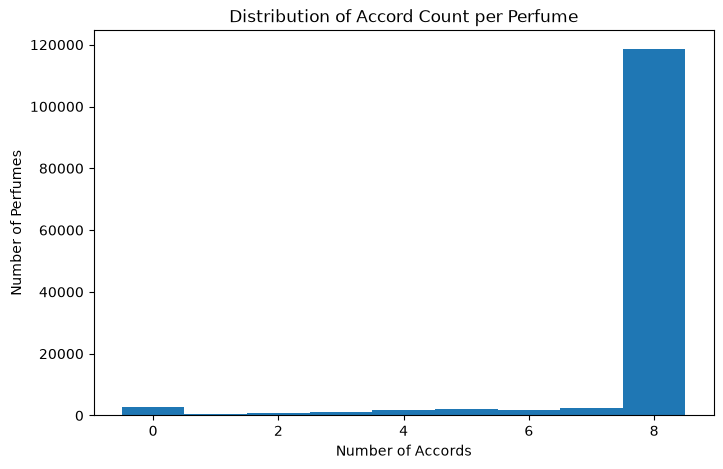

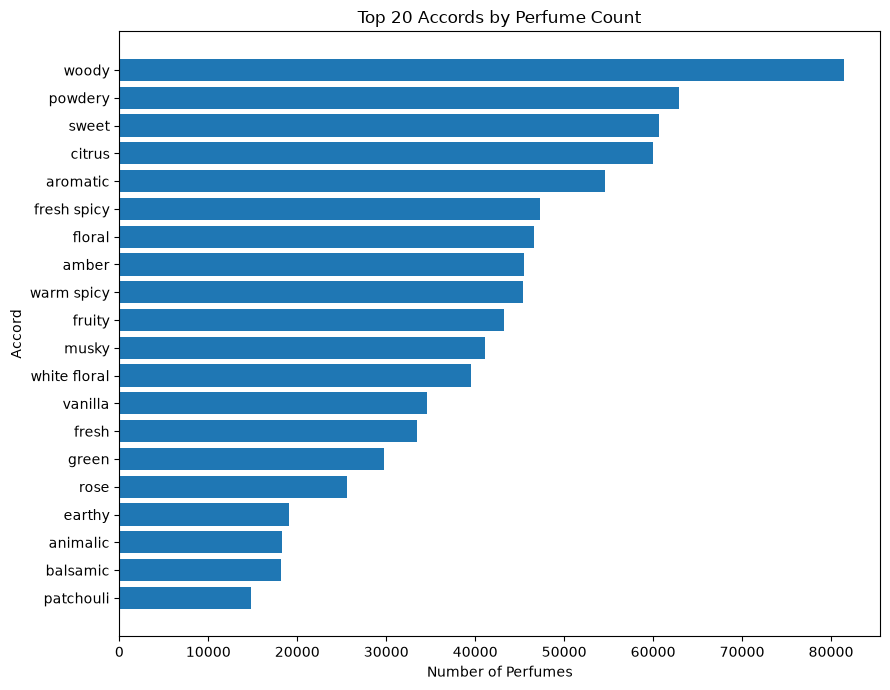

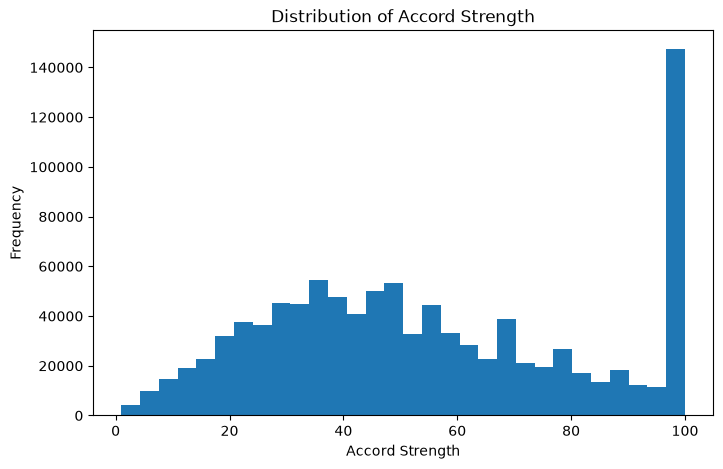

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(accord_count_series, bins=range(int(accord_count_series.max()) + 2), align="left")
plt.title("Distribution of Accord Count per Perfume")
plt.xlabel("Number of Accords")
plt.ylabel("Number of Perfumes")
plt.show()

top_20_for_plot = top_30_accords.head(20).sort_values("등장 향수 수")
plt.figure(figsize=(9, 7))
plt.barh(top_20_for_plot["accord"], top_20_for_plot["등장 향수 수"])
plt.title("Top 20 Accords by Perfume Count")
plt.xlabel("Number of Perfumes")
plt.ylabel("Accord")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(accord_strength_series, bins=30)
plt.title("Distribution of Accord Strength")
plt.xlabel("Accord Strength")
plt.ylabel("Frequency")
plt.show()

## 7. People / Community Vote 분석

`people`은 커뮤니티 집계의 표본 크기를 판단하는 핵심 값입니다. 결측과 실제 0을 구분하고 기초 통계 및 여러 참고 threshold별 규모를 계산하되, 어떤 threshold도 최종 기준으로 결정하지 않습니다.

In [16]:
people_series = pd.Series(np.asarray(people_values), name="people")
people_quantiles = people_series.quantile([0.25, 0.75, 0.90, 0.95, 0.99])

people_summary = pd.Series({
    "데이터 존재 향수 수": people_series.size,
    "데이터 존재 비율": people_series.size / total_jsonl_records,
    "0인 향수 수": (people_series == 0).sum(),
    "평균": people_series.mean(),
    "중앙값": people_series.median(),
    "최소": people_series.min(),
    "25%": people_quantiles.loc[0.25],
    "75%": people_quantiles.loc[0.75],
    "90%": people_quantiles.loc[0.90],
    "95%": people_quantiles.loc[0.95],
    "99%": people_quantiles.loc[0.99],
    "최대": people_series.max(),
})
people_summary.to_frame("값")

,값
데이터 존재 향수 수,121525.000000
데이터 존재 비율,0.921132
0인 향수 수,6173.000000
평균,175.442452
중앙값,15.000000
최소,0.000000
25%,3.000000
75%,71.000000
90%,289.000000
95%,667.000000


### People threshold별 데이터 규모

여러 참고 threshold를 만족하는 향수 수와 전체 대비 비율을 나란히 계산합니다. 아직 적절한 기준을 선택하지 않습니다.

In [17]:
people_thresholds = [1, 5, 10, 20, 50, 100, 500, 1000]
people_threshold_summary = pd.DataFrame([
    {
        "threshold": f"people >= {threshold}",
        "향수 수": int((people_series >= threshold).sum()),
        "전체 향수 대비 비율": (people_series >= threshold).sum() / total_jsonl_records,
    }
    for threshold in people_thresholds
])
people_threshold_summary

,threshold,향수 수,전체 향수 대비 비율
0,people >= 1,115352,0.874342
1,people >= 5,85588,0.648738
2,people >= 10,69987,0.530486
3,people >= 20,54827,0.415576
4,people >= 50,36732,0.278420
5,people >= 100,25141,0.190563
6,people >= 500,7823,0.059297
7,people >= 1000,4108,0.031138


### People 분포 시각화

원래 척도의 분포와 큰 값의 영향을 완화한 `log1p(people)` 분포를 각각 확인합니다.

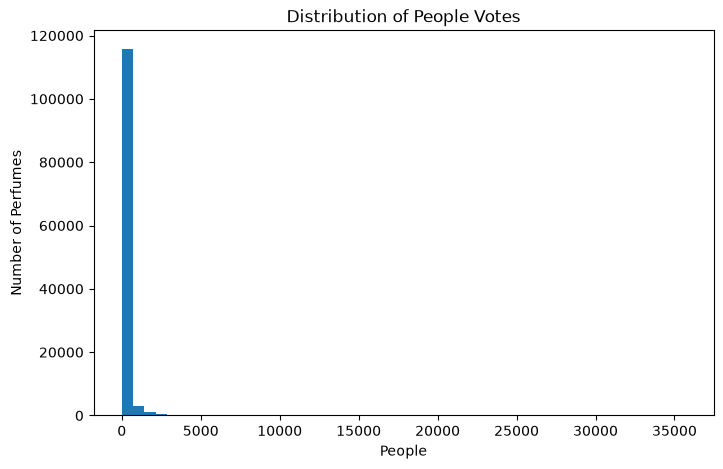

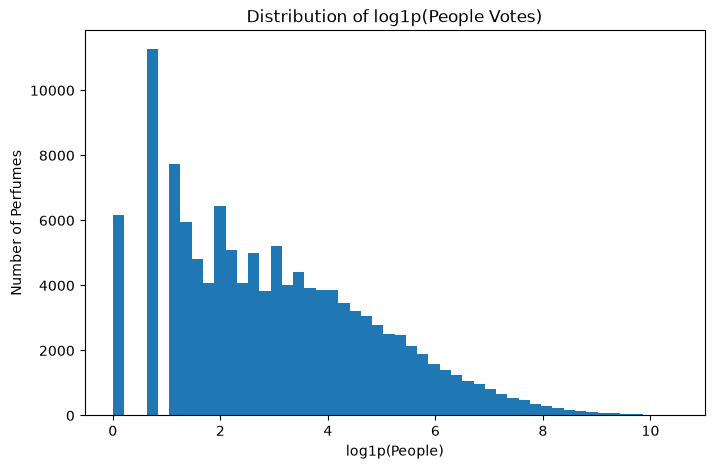

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(people_series, bins=50)
plt.title("Distribution of People Votes")
plt.xlabel("People")
plt.ylabel("Number of Perfumes")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(people_series), bins=50)
plt.title("Distribution of log1p(People Votes)")
plt.xlabel("log1p(People)")
plt.ylabel("Number of Perfumes")
plt.show()

## 8. Season / Daypart 데이터 확인

계절 투표 합과 시간대 투표 합을 계산해 실제 커뮤니티 신호가 있는 레코드 규모를 확인합니다. 원본 객체가 `null`이면 합계를 0으로 바꾸지 않고 NaN으로 유지해 '0표'와 '데이터 없음'을 구분합니다.

In [19]:
season_total_series = pd.Series(np.asarray(season_totals), name="season_total")
daypart_total_series = pd.Series(np.asarray(daypart_totals), name="daypart_total")

season_daypart_counts = pd.Series({
    "season_total 결측": season_total_series.isna().sum(),
    "season_total = 0": season_total_series.eq(0).sum(),
    "season_total > 0": season_total_series.gt(0).sum(),
    "daypart_total 결측": daypart_total_series.isna().sum(),
    "daypart_total = 0": daypart_total_series.eq(0).sum(),
    "daypart_total > 0": daypart_total_series.gt(0).sum(),
})
season_daypart_counts.to_frame("향수 수")

,향수 수
season_total 결측,0
season_total = 0,20579
season_total > 0,111351
daypart_total 결측,0
daypart_total = 0,22371
daypart_total > 0,109559


### Season / Daypart 합계의 분포 요약

결측을 제외한 season_total과 daypart_total의 평균, 중앙값 및 주요 분위수를 비교합니다.

In [20]:
def selected_distribution_summary(series):
    quantiles = series.quantile([0.25, 0.75, 0.90, 0.95, 0.99])
    return pd.Series({
        "평균": series.mean(),
        "중앙값": series.median(),
        "25%": quantiles.loc[0.25],
        "75%": quantiles.loc[0.75],
        "90%": quantiles.loc[0.90],
        "95%": quantiles.loc[0.95],
        "99%": quantiles.loc[0.99],
    })

pd.DataFrame({
    "season_total": selected_distribution_summary(season_total_series),
    "daypart_total": selected_distribution_summary(daypart_total_series),
})

,season_total,daypart_total
평균,170.69975,94.084939
중앙값,14.00000,8.000000
25%,3.00000,2.000000
75%,64.00000,35.000000
90%,259.00000,142.000000
95%,600.00000,331.000000
99%,2823.71000,1557.000000


### People 결측과 season_total 0의 관계

같은 JSONL 레코드 순서를 이용해 people 결측 여부와 season 데이터 상태를 교차 집계합니다. 이렇게 하면 people이 없는 경우가 season 0으로 잘못 해석되는지 확인할 수 있습니다.

In [21]:
people_missing_mask = np.asarray(people_missing_flags, dtype=bool)
season_missing_mask = season_total_series.isna().to_numpy()
season_zero_mask = season_total_series.eq(0).to_numpy()

people_season_relation = pd.Series({
    "people 결측 & season 결측": int((people_missing_mask & season_missing_mask).sum()),
    "people 결측 & season_total = 0": int((people_missing_mask & season_zero_mask).sum()),
    "people 존재 & season_total = 0": int((~people_missing_mask & season_zero_mask).sum()),
})
people_season_relation.to_frame("향수 수")

,향수 수
people 결측 & season 결측,0
people 결측 & season_total = 0,10405
people 존재 & season_total = 0,10174


## 9. Reminds Me Of 관계 분석

방향이 있는 각 관계의 source ID, target ID, 찬성표, 반대표를 메모리 효율적인 임시 배열에 수집했습니다. 관계 규모, 데이터셋 내부 연결 여부, 투표 수와 동의 비율 분포를 확인하되 Golden Set은 생성하지 않습니다.

In [22]:
source_id_values = np.asarray(relation_source_ids)
target_id_values = np.asarray(relation_target_ids)
up_vote_values = np.asarray(relation_up_votes)
down_vote_values = np.asarray(relation_down_votes)

valid_vote_mask = (up_vote_values >= 0) & (down_vote_values >= 0)
total_votes = np.full(len(up_vote_values), np.nan, dtype="float64")
total_votes[valid_vote_mask] = (
    up_vote_values[valid_vote_mask] + down_vote_values[valid_vote_mask]
)

agree_ratio = np.full(len(total_votes), np.nan, dtype="float64")
agree_ratio_mask = valid_vote_mask & (total_votes > 0)
agree_ratio[agree_ratio_mask] = (
    up_vote_values[agree_ratio_mask] / total_votes[agree_ratio_mask]
)

relation_overview = pd.Series({
    "reminds_me_of 보유 향수 수": perfumes_with_reminds_me_of,
    "보유 향수 비율": perfumes_with_reminds_me_of / total_jsonl_records,
    "전체 directed relation 수": len(source_id_values),
    "dataset 내부 target 관계 수": internal_target_relations,
    "dataset 외부 target 관계 수": external_target_relations,
    "투표 값 누락 관계 수": int((~valid_vote_mask).sum()),
    "agree_ratio 계산 가능 관계 수": int(agree_ratio_mask.sum()),
})
relation_overview.to_frame("값")

,값
reminds_me_of 보유 향수 수,91603.00000
보유 향수 비율,0.69433
전체 directed relation 수,692729.00000
dataset 내부 target 관계 수,692726.00000
dataset 외부 target 관계 수,3.00000
투표 값 누락 관계 수,0.00000
agree_ratio 계산 가능 관계 수,692729.00000


### 관계별 투표 threshold 규모

각 threshold를 만족하는 관계 수와 전체 directed relation 대비 비율을 계산합니다. 이는 후보 규모 확인용이며 기준 선택을 의미하지 않습니다.

In [23]:
relation_vote_thresholds = [1, 5, 10, 20, 50, 100]
relation_vote_summary = pd.DataFrame([
    {
        "threshold": f"total_votes >= {threshold}",
        "관계 수": int((total_votes >= threshold).sum()),
        "전체 관계 대비 비율": (total_votes >= threshold).sum() / len(total_votes),
    }
    for threshold in relation_vote_thresholds
])
relation_vote_summary

,threshold,관계 수,전체 관계 대비 비율
0,total_votes >= 1,692729,1.000000
1,total_votes >= 5,333377,0.481252
2,total_votes >= 10,198997,0.287265
3,total_votes >= 20,110028,0.158833
4,total_votes >= 50,46786,0.067539
5,total_votes >= 100,22012,0.031776


### Agree ratio 규모와 Golden Set 후보 규모

`total_votes > 0`이라 agree ratio를 계산할 수 있는 관계만 분모로 사용합니다. 마지막 복합 조건 역시 후보 규모만 보여주며 Golden Set을 실제로 생성하거나 저장하지 않습니다.

In [24]:
agree_thresholds = [0.5, 0.7, 0.8, 0.9]
agree_ratio_count = int(agree_ratio_mask.sum())
agree_ratio_summary = pd.DataFrame([
    {
        "threshold": f"agree_ratio >= {threshold}",
        "관계 수": int((agree_ratio >= threshold).sum()),
        "계산 가능 관계 대비 비율": (
            (agree_ratio >= threshold).sum() / agree_ratio_count
            if agree_ratio_count else np.nan
        ),
    }
    for threshold in agree_thresholds
])
agree_ratio_summary

,threshold,관계 수,계산 가능 관계 대비 비율
0,agree_ratio >= 0.5,505459,0.729663
1,agree_ratio >= 0.7,254271,0.367057
2,agree_ratio >= 0.8,215568,0.311187
3,agree_ratio >= 0.9,187746,0.271024


### 복합 조건을 만족하는 관계 규모

지정된 투표 수와 동의 비율 조건을 동시에 만족하는 관계 수만 계산해 이후 Golden Set 후보 규모를 가늠합니다.

In [25]:
golden_candidate_mask = (total_votes >= 20) & (agree_ratio >= 0.8)
print(
    "total_votes >= 20 AND agree_ratio >= 0.8 조건을 만족하는 관계 수: "
    f"{int(golden_candidate_mask.sum()):,}"
)

total_votes >= 20 AND agree_ratio >= 0.8 조건을 만족하는 관계 수: 12,794


### Reminds Me Of 분포 시각화

유효한 투표 합계의 `log1p` 분포와 계산 가능한 agree ratio 분포를 각각 별도의 그래프로 확인합니다.

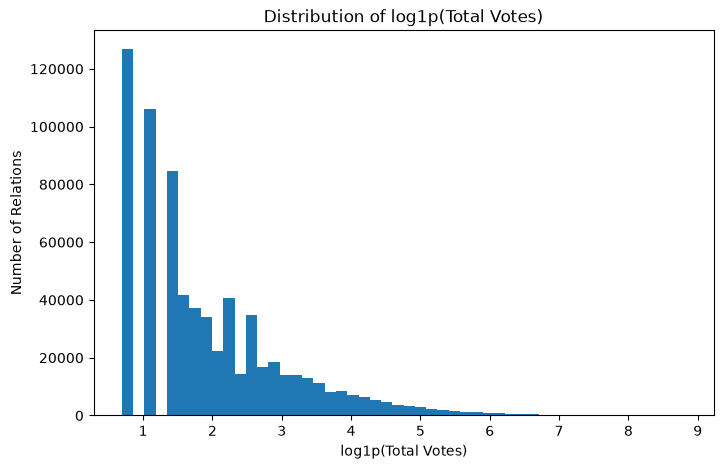

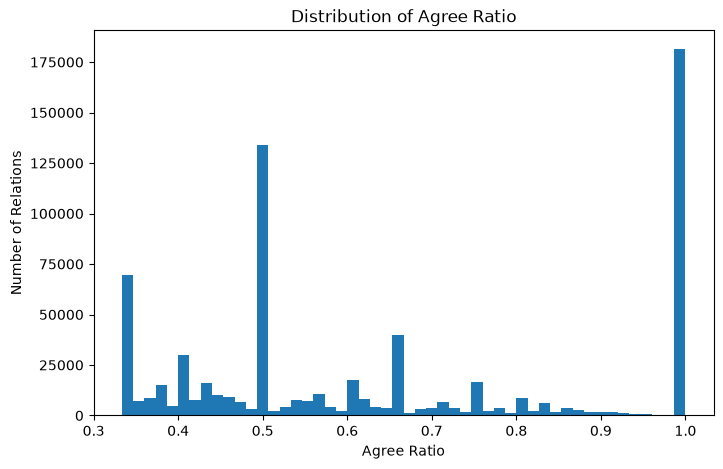

In [26]:
valid_total_votes = total_votes[valid_vote_mask]
valid_agree_ratios = agree_ratio[agree_ratio_mask]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(valid_total_votes), bins=50)
plt.title("Distribution of log1p(Total Votes)")
plt.xlabel("log1p(Total Votes)")
plt.ylabel("Number of Relations")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(valid_agree_ratios, bins=50)
plt.title("Distribution of Agree Ratio")
plt.xlabel("Agree Ratio")
plt.ylabel("Number of Relations")
plt.show()

## 10. 최종 데이터 품질 요약 템플릿

아래 항목은 위에서 실제 계산된 결과를 확인한 뒤 사람이 직접 작성합니다. 계산 결과와 해석 또는 추측을 구분해 기록합니다.

## 데이터 무결성
- 전체 향수 수:
- 중복 ID:
- 주요 기본 정보 결측:

## Notes
- Tiered:
- Flat:
- Notes 없음:
- 비정상 both:

## Accords
- Accord 보유율:
- 고유 Accord 수:
- 향수당 Accord 중앙값:
- 주요 Accord 편향 여부:

## Community Data
- people 데이터 보유율:
- people 중앙값:
- 충분한 투표가 있는 데이터 규모:

## CSV / JSONL 결측 표현
- JSONL null이 CSV에서 어떻게 표현되는지:

## Reminds Me Of
- 관계 보유 향수:
- 전체 관계 수:
- 투표가 충분한 관계 수:
- Golden Set 후보로 사용할 가능성:

## 현재 판단
- 추천 핵심 피처 후보:
- 신뢰도 보정이 필요한 데이터:
- 다음 분석에서 확인할 사항: